In [ ]:
# base_path = "/home/student/sky-scan/data"
#
#
# from PIL import Image
# import os
#
# def get_all_char_before_dot(s):
#     dot_index = s.find('.')
#     if dot_index > 0:
#         return s[:dot_index]
#     else:
#         return None  # Return None if there's no character before the dot
#
# def generate_tiles(image_path, tile_width, tile_height, step, output_folder):
#     # Open the image
#     image = Image.open(image_path)
#     image_width, image_height = image.size
#
#     # Generate tiles
#     for x in range(0, image_width - tile_width + 1, step):
#         for y in range(0, image_height - tile_height + 1, step):
#             # Define the bounding box for the current tile
#             left = x
#             upper = y
#             right = left + tile_width
#             lower = upper + tile_height
#             bbox = (left, upper, right, lower)
#
#             # Crop the image to the bounding box to create the tile
#             tile = image.crop(bbox)
#
#             # Save the tile to the output folder
#             image_file_name=os.path.basename(image_path)
#             image_idx = get_all_char_before_dot(image_file_name)
#             tile.save(f"{output_folder}/{image_idx}_{x}_{y}.png") #image_id_x_y.png
#
#     print(f"✅ Tiles from {image_file_name} are generated successfully.")
#
# def generate_binary_tiles(image_path, tile_width, tile_height, step, output_folder):
#     # Open the image in grayscale mode (black & white)
#     image = Image.open(image_path).convert("L")  # "L" mode ensures grayscale (0-255)
#     image_width, image_height = image.size
#
#     # Generate tiles
#     for x in range(0, image_width - tile_width + 1, step):
#         for y in range(0, image_height - tile_height + 1, step):
#             # Define the bounding box for the current tile
#             left = x
#             upper = y
#             right = left + tile_width
#             lower = upper + tile_height
#             bbox = (left, upper, right, lower)
#
#             # Crop the image to create the tile
#             tile = image.crop(bbox)
#
#             # Convert to binary (0 or 255) to ensure black and white format
#             tile = tile.point(lambda p: 255 if p > 127 else 0, mode="1")  # Thresholding
#
#             # Save the tile to the output folder
#             image_file_name = os.path.basename(image_path)
#             image_idx = image_file_name.split('.')[0]  # Get filename without extension
#             tile.save(f"{output_folder}/{image_idx}_{x}_{y}.png", format="PNG")  # Save as binary PNG
#
#     print(f"✅ Binary tiles from {image_file_name} are generated successfully.")
#
# # Generate tiles for original images
# # os.makedirs(f'{base_path}/patch', exist_ok=True)
# #
# # for i in range(1,13): #12 images
# #     generate_tiles(f'{base_path}/Tiles/{i}.jpg', 256, 256, 128, f'{base_path}/patch')
# #
# # print("Original images are generated successfully.")
#
# # # Generate tiles for binary mask images
# # os.makedirs(f'{base_path}/patch-colour', exist_ok=True)
# #
# # for i in range(1,13): #12 images
# #     generate_tiles(f'{base_path}/colour_mask/{i}.png', 256, 256, 128, f'{base_path}/patch-colour')
# #
# # print("Binary mask images are generated successfully.")
#
# os.makedirs(f'{base_path}/patch-texture', exist_ok=True)
#
# for i in range(1,13): #12 images
#     generate_tiles(f'{base_path}/texture_mask/{i}.png', 256, 256, 128, f'{base_path}/patch-texture')
#
# print("Texture mask images are generated successfully.")

In [ ]:
# # Uninstall existing versions
# !pip uninstall torch torchvision -y
#
# # Install compatible versions
# !pip install torch==2.1.2 torchvision==0.16.2
# import torch
# print(torch.__version__)  # Should be 2.1.2+cu121
# import torchvision
# print(torchvision.__version__)

In [ ]:
# # Install required packages (uncomment if running in a notebook environment)
# # !pip install torch==1.13.1 torchvision==0.14.1 numpy matplotlib opencv-python pillow
# # !pip install tqdm
#
# # Import necessary libraries
# import os
# import cv2
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt
# from PIL import Image
# import torchvision.transforms as transforms
# from torch.utils.data import Dataset, DataLoader
# from sklearn.model_selection import train_test_split
# from tqdm import tqdm
# import warnings
#
# # Suppress specific warnings
# warnings.simplefilter('ignore', Image.DecompressionBombWarning)
#
# # Base path for data
# base_path = "/home/student/sky-scan/data"
# image_dir = f"{base_path}/patch"  # Folder with image tiles
# mask_dir = f"{base_path}/patch-texture"  # Folder with corresponding mask tiles
#
# # Check if CUDA is available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.cuda.is_available():
#     print(f"✅ Running on GPU: {torch.cuda.get_device_name(0)}")
# else:
#     print("⚠️ No GPU detected, running on CPU.")
#
# # Set random seed for reproducibility
# torch.manual_seed(42)
#
# # Function to load tiled data
# def load_tiled_data(image_dir, mask_dir, image_size=(256, 256)):
#     image_files = os.listdir(image_dir)
#     images = []
#     masks = []
#
#     for image_file in tqdm(image_files, desc="Loading images", unit="image"):
#         img_path = os.path.join(image_dir, image_file)
#         mask_path = os.path.join(mask_dir, image_file)
#
#         if not os.path.exists(mask_path):
#             continue
#
#         # Load and preprocess image
#         image = Image.open(img_path).convert("RGB")
#         image = image.resize(image_size)
#         image = np.array(image) / 255.0  # Normalize to [0, 1]
#
#         # Load and preprocess mask
#         mask = Image.open(mask_path).convert("RGB")
#         mask = mask.resize(image_size)
#         mask = np.array(mask) / 255.0  # Normalize to [0, 1]
#
#         images.append(image)
#         masks.append(mask)
#
#     return np.array(images), np.array(masks)
#
# # Custom Dataset Class
# class BuildingMaterialDataset(Dataset):
#     def __init__(self, images, masks, transform=None):
#         self.images = images
#         self.masks = masks
#         self.transform = transform
#
#     def __len__(self):
#         return len(self.images)
#
#     def __getitem__(self, idx):
#         image = self.images[idx]
#         mask = self.masks[idx]
#
#         if self.transform:
#             image = self.transform(image)
#             mask = transforms.ToTensor()(mask)
#
#         # Convert mask RGB to class indices
#         mask = self.rgb_to_class(mask)
#         return image, mask
#
#     def rgb_to_class(self, mask):
#         # Convert RGB mask to class indices
#         mask = mask.permute(1, 2, 0).numpy() * 255  # Convert back to [0, 255] range
#         class_map = {
#             (255, 0, 0): 0,    # Red: Material 1 (e.g., concrete)
#             (0, 255, 0): 1,    # Green: Material 2 (e.g., metal)
#             (0, 0, 255): 2,    # Blue: Material 3 (e.g., wood)
#             (0, 0, 0): 3       # Black: Background
#         }
#         h, w, _ = mask.shape
#         label_idx = np.zeros((h, w), dtype=np.int64)
#         for rgb, idx in class_map.items():
#             mask_rgb = np.array(rgb)
#             mask_compare = np.all(mask == mask_rgb, axis=-1)
#             label_idx[mask_compare] = idx
#         return torch.tensor(label_idx, dtype=torch.long)
#
# # Data Preprocessing
# transform = transforms.Compose([
#     transforms.ToTensor(),  # Convert to tensor
# ])
#
# # Load dataset
# # X, Y = load_tiled_data(image_dir, mask_dir)
# # print(f"✅ Loaded {len(X)} images and {len(Y)} coloured masks.")

In [ ]:
# from torch.utils.data import TensorDataset, DataLoader
# from tqdm import tqdm
#
# # Convert to PyTorch tensors with explicit float type
# X_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
# Y_tensor = torch.tensor(Y, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
#
# train_dataset = TensorDataset(X_tensor, Y_tensor)
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
#
# # Wrap the DataLoader with tqdm for progress bar
# train_loader = tqdm(train_loader, desc="Training", unit="batch")
#
# # Example of iterating through the DataLoader with progress bar
# for batch in train_loader:
#     images, labels = batch

In [ ]:

# Calculate the starting index for the middle 10 images
middle_start_index = 90

# Select a range of 10 images starting from the middle index
fixed_indices = list(range(middle_start_index, middle_start_index + 10))

# Ensure the indices are within the valid range
fixed_indices = [i for i in fixed_indices if i < len(X_tensor)]

# Select the images and masks
fixed_images = X_tensor[fixed_indices]
fixed_masks = Y_tensor[fixed_indices]

# Display Results
plt.figure(figsize=(20, 10))
for i, (image, mask) in enumerate(zip(fixed_images.cpu(), fixed_masks.cpu())):
    plt.subplot(2, 10, i + 1)
    plt.imshow(image.permute(1, 2, 0).cpu().numpy())  # Normalize visualization if needed
    plt.title(f"Image {i + 1}")
    plt.axis('off')

    plt.subplot(2, 10, i + 11)
    plt.imshow(mask.permute(1, 2, 0).cpu().numpy())  # Display mask as color image
    plt.title(f"Mask {i + 1}")
    plt.axis('off')
plt.show()

In [ ]:
# # Define CNN Model
# class CNNModel(nn.Module):
#     def __init__(self, num_classes):
#         super(CNNModel, self).__init__()
#         self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
#         self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
#         self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
#         self.fc1 = nn.Linear(128 * 32 * 32, 256)
#         self.dropout = nn.Dropout(0.5)
#         self.fc2 = nn.Linear(256, num_classes)
#
#     def forward(self, x):
#         x = self.pool(torch.relu(self.conv1(x)))
#         x = self.pool(torch.relu(self.conv2(x)))
#         x = self.pool(torch.relu(self.conv3(x)))
#         x = torch.flatten(x, start_dim=1)
#         x = torch.relu(self.fc1(x))
#         x = self.dropout(x)
#         x = self.fc2(x)
#         return x
#
# # Initialize Model
# num_classes = len(np.unique(Y))
# model = CNNModel(num_classes)
#
# # Define Loss and Optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
#
# # Device Configuration
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
#
# # Checkpoint Saving
# checkpoint_path = "best_model.pth"
#
# # Training Loop
# epochs = 20
# best_val_loss = float('inf')
# train_losses = []
#
# for epoch in range(epochs):
#     model.train()
#     running_loss = 0.0
#     for images, labels in train_loader:
#         images, labels = images.to(device), labels.to(device)
#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()
#
#     train_loss = running_loss / len(train_loader)
#     train_losses.append(train_loss)
#
#     print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}")
#
#     # Save best model
#     if train_loss < best_val_loss:
#         best_val_loss = train_loss
#         torch.save(model.state_dict(), checkpoint_path)
#
# # Plot Training History
# plt.plot(train_losses, label='Train Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.show()
#
# # Select and Evaluate 10 Fixed Images
# fixed_indices = list(range(10))  # Select the first 10 images consistently
# fixed_images = X_tensor[fixed_indices].to(device)
# model.eval()
# with torch.no_grad():
#     predictions = model(fixed_images)
# predicted_classes = torch.argmax(predictions, dim=1)
#
# # Display Results
# for i, (image, pred) in enumerate(zip(fixed_images.cpu(), predicted_classes.cpu())):
#     plt.subplot(2, 5, i+1)
#     plt.imshow(image.permute(1, 2, 0))  # Normalize visualization if needed
#     plt.title(f"Pred: {pred.item()}")
#     plt.axis('off')
# plt.show()


In [ ]:
# import os
# import numpy as np
# from PIL import Image
# from tqdm import tqdm
# import warnings
# import matplotlib.pyplot as plt
# import random
#
# # Define constants
# IMG_HEIGHT = 256
# IMG_WIDTH = 256
# base_path = "/home/student/sky-scan/data"
# texture_classes = {
#     0: {'name': 'rough', 'color': [255, 0, 0]},    # Red
#     1: {'name': 'average', 'color': [255, 255, 0]}, # Yellow
#     2: {'name': 'smooth', 'color': [0, 255, 0]}     # Green
# }
#
# # Suppress DecompressionBombWarning specifically
# warnings.simplefilter('ignore', Image.DecompressionBombWarning)
# Image.MAX_IMAGE_PIXELS = None
#
# # Function to load tiled data
# def load_tiled_data(image_dir, mask_dir, image_size=(256, 256)):
#     image_files = os.listdir(image_dir)
#     images = []
#     masks = []
#
#     for image_file in tqdm(image_files, desc="Loading images", unit="image"):
#         img_path = os.path.join(image_dir, image_file)
#         mask_path = os.path.join(mask_dir, image_file)
#
#         if not os.path.exists(mask_path):
#             continue
#
#         # Load and preprocess image
#         image = Image.open(img_path)
#         image = image.resize(image_size)
#         image = np.array(image) / 255.0  # Normalize to [0, 1]
#
#         # Load and preprocess mask
#         mask = Image.open(mask_path).convert("RGB")
#         mask = mask.resize(image_size)
#         mask = np.array(mask) / 255.0  # Normalize to [0, 1]
#
#         images.append(image)
#         masks.append(mask)
#
#     return np.array(images), np.array(masks)
#
# # Function to load tiled data and assign labels
# def load_and_label_data(image_dir, mask_dir, image_size=(256, 256)):
#     image_files = sorted(os.listdir(image_dir))  # Sort for consistent order
#     images = []
#     masks = []
#     filenames = []
#     labels = []  # Store labels for each image
#
#     for image_file in tqdm(image_files, desc="Loading and labeling images", unit="image"):
#         img_path = os.path.join(image_dir, image_file)
#         mask_file = image_file  # Same filename for mask
#         mask_path = os.path.join(mask_dir, mask_file)
#
#         if not os.path.exists(mask_path):
#             print(f"Warning: Mask not found for {image_file}, skipping.")
#             continue
#
#         try:
#             # Load and preprocess image
#             image = Image.open(img_path).convert("RGB")
#             image = image.resize(image_size)
#             image = np.array(image) / 255.0
#         except Exception as e:
#             print(f"Warning: Failed to load image {img_path}: {e}")
#             continue
#
#         try:
#             # Load mask as RGB
#             mask = Image.open(mask_path).convert("RGB")
#             mask = mask.resize(image_size, Image.NEAREST)
#             mask = np.array(mask)
#         except Exception as e:
#             print(f"Warning: Failed to load mask {mask_path}: {e}")
#             continue
#
#         # Determine which classes are present in the mask
#         unique_colors = np.unique(mask.reshape(-1, 3), axis=0)
#         present_classes = []
#         for class_id, class_info in texture_classes.items():
#             color = np.array(class_info['color'])
#             # Check if this color is present (with slight tolerance for compression artifacts)
#             if any(np.all(np.abs(unique_colors - color) <= 5, axis=1)):
#                 present_classes.append(class_id)
#
#         # Assign label based on present classes
#         if not present_classes:
#             label = "unknown"  # Handle cases with no recognized colors
#         else:
#             label = "_".join(texture_classes[cls]['name'] for cls in sorted(present_classes))
#
#         # print(f"File {image_file} - Unique colors: {unique_colors}, Label: {label}")
#
#         images.append(image)
#         masks.append(mask)
#         filenames.append(image_file)
#         labels.append(label)
#
#     return np.array(images), np.array(masks), filenames, labels
#
#
# # Load data
# image_dir = f"{base_path}/patch-binary"
# mask_dir = f"{base_path}/patch-texture"
# images, masks = load_tiled_data(image_dir, mask_dir)
# print(f"Loaded {len(images)} images and {len(masks)} masks")
# # images, masks, filenames, labels = load_and_label_data(image_dir, mask_dir)
# # print(f"Loaded {len(images)} images and {len(masks)} masks")

In [ ]:

import cv2
# # Function to visualize 10 random images with their RGB color masks
# def visualize_random_images(images, masks, num_images=10):
#     num_images = min(num_images, len(images))
#     random_indices = random.sample(range(len(images)), num_images)
#
#     fig, axes = plt.subplots(num_images, 2, figsize=(10, 5 * num_images))
#     fig.suptitle("Original Images and Their RGB Color Masks", fontsize=16)
#
#     for i, idx in enumerate(random_indices):
#         img = images[idx]
#         mask_rgb = masks[idx]  # Directly use the RGB mask
#
#         # Plot original image
#         axes[i, 0].imshow(img)
#         axes[i, 0].set_title(f"Original: {idx}")
#         axes[i, 0].axis('off')
#
#         # Plot RGB mask
#         axes[i, 1].imshow(mask_rgb)
#         axes[i, 1].set_title(f"Mask: {idx}")
#         axes[i, 1].axis('off')
#
#     plt.tight_layout()
#     plt.show()


# # Function to find contours and draw circles for each color
# def draw_circles_in_contours(mask):
#     mask_with_circles = mask.copy()
#     colors = [np.array(info['color']) for info in texture_classes.values()]
#     tolerance = 5  # Tolerance for color matching
#
#     for color_idx, color in enumerate(colors):
#         # Create a binary mask for the current color with tolerance
#         binary_mask = np.all(np.abs(mask - color) <= tolerance, axis=-1).astype(np.uint8) * 255
#
#         # Debug: Check if this color is detected
#         if np.any(binary_mask):
#             print(f"Detected color {color} in mask")
#
#         # Find contours
#         contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#
#         # Draw circles inside each contour
#         for contour in contours:
#             # Filter small contours (optional)
#             if cv2.contourArea(contour) > 50:  # Ignore very small noise contours
#                 (x, y), radius = cv2.minEnclosingCircle(contour)
#                 center = (int(x), int(y))
#                 radius = int(radius * 0.8)  # Reduce radius to fit inside
#
#                 # Use different colors for each class for visibility
#                 circle_color = tuple(int(c) for c in colors[color_idx])  # Match contour color
#                 cv2.circle(mask_with_circles, center, radius, circle_color, 2)
#
#     return mask_with_circles

# # Function to find contours and draw white circles for each color
# def draw_circles_in_contours(mask):
#     mask_with_circles = mask.copy()
#     colors = [np.array(info['color']) for info in texture_classes.values()]
#     tolerance = 5  # Tolerance for color matching
#
#     for color in colors:
#         # Create a binary mask for the current color with tolerance
#         binary_mask = np.all(np.abs(mask - color) <= tolerance, axis=-1).astype(np.uint8) * 255
#
#         # Debug: Check if this color is detected
#         if np.any(binary_mask):
#             print(f"Detected color {color} in mask")
#
#         # Find contours
#         contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#
#         # Draw white circles inside each contour
#         for contour in contours:
#             if cv2.contourArea(contour) > 50:  # Ignore small noise contours
#                 (x, y), radius = cv2.minEnclosingCircle(contour)
#                 center = (int(x), int(y))
#                 radius = int(radius * 0.8)  # Reduce radius to fit inside
#
#                 # Draw white circle
#                 cv2.circle(mask_with_circles, center, radius, (255, 255, 255), 2)
#
#     return mask_with_circles
#
# def draw_colored_contours_with_circles(image_input, black_tolerance=0, circle_color=(255, 255, 255), thickness=2):
#     """
#     Draw contours and circles on an image, ignoring black background and small contours.
#
#     Parameters:
#     - image_input: numpy array, input image in BGR format
#     - black_tolerance: int, tolerance for black color detection
#     - circle_color: tuple, BGR color for circles
#     - thickness: int, thickness of circle lines
#     """
#     # Work on a copy of the input image
#     image = image_input.copy()
#
#     # Convert BGR to RGB for color processing
#     image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#
#     # Create mask for non-black pixels with tolerance
#     if black_tolerance == 0:
#         black_mask = np.all(image_rgb == [0, 0, 0], axis=-1)
#     else:
#         black_mask = np.all(np.abs(image_rgb - [0, 0, 0]) <= black_tolerance, axis=-1)
#
#     # Create working copy with white background
#     masked_image = image_rgb.copy()
#     masked_image[black_mask] = [255, 255, 255]
#
#     # Convert to grayscale and create binary image
#     gray = cv2.cvtColor(masked_image, cv2.COLOR_RGB2GRAY)
#     _, binary = cv2.threshold(gray, 254, 255, cv2.THRESH_BINARY_INV)
#
#     # Find contours
#     contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#
#     # Draw circles inside valid contours
#     output_image = image.copy()
#     for contour in contours:
#         # Skip small contours
#         if cv2.contourArea(contour) < 50:
#             continue
#
#         # Find enclosing circle
#         (x, y), radius = cv2.minEnclosingCircle(contour)
#         center = (int(x), int(y))
#         radius = int(radius * 0.7)  # Make circle smaller to fit inside contour
#
#         # Draw circle
#         cv2.circle(output_image, center, radius, circle_color, thickness)
#
#     return output_image
#
# def visualize_random_images(images, masks, num_images=10):
#     # Select random indices
#     num_images = min(num_images, len(images))
#     random_indices = random.sample(range(len(images)), num_images)
#
#     # Create figure
#     fig, axes = plt.subplots(num_images, 2, figsize=(12, 5 * num_images))
#     fig.suptitle("Original Images and Masks with Circles", fontsize=16)
#
#     for i, idx in enumerate(random_indices):
#         # Get image and mask
#         img = images[idx]
#         mask_rgb = masks[idx]
#
#         # Convert mask to uint8 for OpenCV
#         mask_rgb_cv = (mask_rgb * 255).astype(np.uint8)
#
#         # Draw contours and circles
#         result_image = draw_colored_contours_with_circles(
#             cv2.cvtColor(mask_rgb_cv, cv2.COLOR_RGB2BGR),
#             black_tolerance=10,
#             circle_color=(255, 255, 255),  # White circles
#             thickness=2
#         )
#
#         # Convert result back to RGB
#         result_image = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)
#
#         # Plot original image
#         axes[i, 0].imshow(img,cmap= 'gray')
#         axes[i, 0].set_title(f"Original Image {idx}")
#         axes[i, 0].axis('off')
#
#         # Plot mask with circles
#         axes[i, 1].imshow(result_image)
#         axes[i, 1].set_title(f"Mask with Circles {idx}")
#         axes[i, 1].axis('off')
#
#     plt.tight_layout()
#     plt.show()
#
# # Call the function
# visualize_random_images(images, masks, num_images=10)

In [ ]:
# import cv2
# import numpy as np
# import random
# import matplotlib.pyplot as plt
# from tqdm import tqdm
#
# def get_largest_contour_square(image_input, black_tolerance=10):
#     """
#     Extract the largest contour and return a normalized 20x20 square region with its label.
#
#     Parameters:
#     - image_input: numpy array, input image in BGR format
#     - black_tolerance: int, tolerance for black color detection
#
#     Returns:
#     - normalized_square: 20x20 numpy array of the extracted region
#     - label: str, label based on dominant color (rough, average, smooth)
#     """
#     # Work on a copy of the input image
#     image = image_input.copy()
#
#     # Convert BGR to RGB for color processing
#     image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#
#     # Create mask for non-black pixels with tolerance
#     black_mask = np.all(np.abs(image_rgb - [0, 0, 0]) <= black_tolerance, axis=-1)
#
#     # Create working copy with white background
#     masked_image = image_rgb.copy()
#     masked_image[black_mask] = [255, 255, 255]
#
#     # Convert to grayscale and create binary image
#     gray = cv2.cvtColor(masked_image, cv2.COLOR_RGB2GRAY)
#     _, binary = cv2.threshold(gray, 254, 255, cv2.THRESH_BINARY_INV)
#
#     # Find contours
#     contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#
#     if not contours:
#         return None, "No contour"
#
#     # Find the largest contour by area
#     largest_contour = max(contours, key=cv2.contourArea)
#
#     # Skip if largest contour is too small
#     if cv2.contourArea(largest_contour) < 50:
#         return None, "Small contour"
#
#     # Find enclosing circle
#     (x, y), radius = cv2.minEnclosingCircle(largest_contour)
#     center = (int(x), int(y))
#     radius = int(radius)  # Use full radius for square
#
#     # Calculate square bounds
#     half_size = int(radius * 1.414 / 2)  # Half of square diagonal (radius * sqrt(2))
#     x_min = max(0, center[0] - half_size)
#     x_max = min(image.shape[1], center[0] + half_size)
#     y_min = max(0, center[1] - half_size)
#     y_max = min(image.shape[0], center[1] + half_size)
#
#     # Extract square region
#     square_region = image_rgb[y_min:y_max, x_min:x_max]
#
#     # Resize to 20x20
#     normalized_square = cv2.resize(square_region, (20, 20), interpolation=cv2.INTER_AREA)
#
#     # Determine the label based on the dominant color
#     dominant_color = np.mean(normalized_square, axis=(0, 1))
#     if np.all(dominant_color < [85, 85, 85]):
#         label = "rough"
#     elif np.all(dominant_color < [170, 170, 170]):
#         label = "average"
#     else:
#         label = "smooth"
#
#     return normalized_square, label
#
# def extract_patches_and_labels(images, masks, target_size=(20, 20)):
#     """
#     Extract 20x20 patches and labels from all images.
#
#     Parameters:
#     - images: numpy array of original images
#     - masks: numpy array of mask images
#     - target_size: tuple of (height, width) for the extracted patches
#
#     Returns:
#     - patches: list of normalized 20x20 patches
#     - labels: list of labels for the patches
#     """
#     patches = []
#     labels = []
#
#     for idx in tqdm(range(len(images)), desc="Extracting patches"):
#         # Get image and mask
#         img = images[idx]
#         mask_rgb = masks[idx]
#
#         # Convert mask to uint8 for OpenCV
#         mask_rgb_cv = (mask_rgb * 255).astype(np.uint8)
#
#         # Get normalized square from largest contour
#         normalized_square, label = get_largest_contour_square(
#             cv2.cvtColor(mask_rgb_cv, cv2.COLOR_RGB2BGR),
#             black_tolerance=10
#         )
#
#         if normalized_square is None:
#             # If no valid contour, resize the mask to 20x20
#             normalized_square = cv2.resize(mask_rgb_cv, target_size, interpolation=cv2.INTER_AREA)
#             label = "no_contour"
#
#         patches.append(normalized_square)
#         labels.append(label)
#
#     return patches, labels
# # Extract patches and labels
# patches, labels = extract_patches_and_labels(images, masks)

In [ ]:
# import torch
# # Convert the list of patches to a NumPy array
# patches_array = np.array(patches)
#
# label_map = {'rough': 0, 'average': 1, 'smooth': 2, 'no_contour': 3}
# numerical_labels = [label_map[label] for label in labels]
#
#
# # Convert to torch tensors
# X = torch.FloatTensor(patches_array.transpose(0, 3, 1, 2))  # Shape: [N, C, H, W]
# y = torch.LongTensor(numerical_labels)  # Shape: [N]
#   # Shape: [N]
#  # Shape: [N]
#
# # Save the data
# torch.save({
#     'patches': X,
#     'labels': y
# }, 'texture_classification_data.pt')
#
# # Visualize some random patches
# # visualize_random_patches(X, y)

In [ ]:
# print(patches[100])

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
#
# def visualize_random_patches(patches, labels, num_patches=25):
#     num_patches = min(num_patches, len(patches))
#     indices = np.random.choice(len(patches), num_patches, replace=False)
#
#     fig, axes = plt.subplots(5, 5, figsize=(12, 12))
#     fig.suptitle("Random 20x20 Patches with Labels", fontsize=16)
#
#     label_names = ['rough', 'average', 'smooth', 'no_building']
#
#     for idx, ax in enumerate(axes.flat):
#         if idx < num_patches:
#             # Convert tensor to numpy array and transpose to (H, W, C)
#             patch = patches[indices[idx]].numpy().transpose(1, 2, 0)
#
#             # Normalize values to [0, 1] range if needed
#             if patch.max() > 1.0:
#                 patch = patch / 255.0
#
#             # Get label
#             label = labels[indices[idx]].item()
#
#             # Display patch with correct colormap
#             ax.imshow(patch)
#             ax.set_title(f"{label_names[label]}")
#             ax.axis('off')
#
#     plt.tight_layout()
#     plt.show()
#
# # Visualize random patches
# visualize_random_patches(X, y)

In [ ]:
# import torch.nn as nn
# from torchvision.models import resnet18
# from torch.utils.data import Dataset, DataLoader
# from sklearn.model_selection import train_test_split
#
# # Custom Dataset class
# class TextureDataset(Dataset):
#     def __init__(self, patches, labels):
#         self.patches = patches
#         self.labels = labels
#
#     def __len__(self):
#         return len(self.labels)
#
#     def __getitem__(self, idx):
#         return self.patches[idx], self.labels[idx]
#
# # Load saved data
# data = torch.load('texture_classification_data.pt')
# X = data['patches']  # Shape: [N, 3, 20, 20]
# y = data['labels']   # Shape: [N]
#
# # Split into train and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#
# # Create datasets and dataloaders
# train_dataset = TextureDataset(X_train, y_train)
# test_dataset = TextureDataset(X_test, y_test)
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
#
# # Set up the ResNet model
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#
# print('Device:', device)
# model = resnet18(pretrained=False, num_classes=3).to(device)
# model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False).to(device)  # Adjust for 20x20
# model.maxpool = nn.Identity().to(device)  # Remove max pooling
#
# # Loss and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#
# # Training loop
# num_epochs = 20
# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0
#     for inputs, labels in train_loader:
#         inputs, labels = inputs.to(device), labels.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item() * inputs.size(0)
#
#     epoch_loss = running_loss / len(train_loader.dataset)
#     print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')
#
#     # Evaluate on test set
#     model.eval()
#     correct = 0
#     total = 0
#     with torch.no_grad():
#         for inputs, labels in test_loader:
#             inputs, labels = inputs.to(device), labels.to(device)
#             outputs = model(inputs)
#             _, predicted = torch.max(outputs, 1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
#     accuracy = correct / total
#     print(f'Test Accuracy: {accuracy:.4f}')
#
# # Save the trained model
# torch.save(model.state_dict(), 'resnet_texture_classifier.pth')

In [1]:
import os
import numpy as np
from PIL import Image
import cv2
from tqdm import tqdm

# Define paths to your tiled data
base_path = "/home/student/sky-scan/data"
original_dir = f"{base_path}/patch"
binary_dir = f"{base_path}/patch-binary"
color_dir = f"{base_path}/patch-texture"
images_, binary_masks_, color_masks_ = [], [], []
def load_tiled_data(original_dir, binary_dir, color_dir):

    filenames = sorted(os.listdir(original_dir))

    for filename in tqdm(filenames, desc="Loading tiles", unit="tile"):
        # Load original tile
        img_path = os.path.join(original_dir, filename)
        image = Image.open(img_path).convert("RGB")
        images_.append(np.array(image) / 255.0)  # Normalize to [0, 1]

        # Load binary mask tile
        binary_path = os.path.join(binary_dir, filename)
        binary = Image.open(binary_path).convert("L")  # Grayscale
        binary_masks_.append(np.array(binary) / 255.0)  # 0 or 1

        # Load color mask tile
        color_path = os.path.join(color_dir, filename)
        color = Image.open(color_path).convert("RGB")
        color_masks_.append(np.array(color) / 255.0)  # Normalize to [0, 1]

images = np.array(images_)
binary_masks = np.array(binary_masks_)
color_masks = np.array(color_masks_)

load_tiled_data(original_dir, binary_dir, color_dir)

Loading tiles: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16200/16200 [01:43<00:00, 156.92tile/s]


In [1]:
import numpy as np
import torch
import cv2

def get_largest_contour_square(image_input, black_tolerance=10):
    """
    Extract the largest contour and return a normalized 20x20 square region with its label.

    Parameters:
    - image_input: numpy array, input image in BGR format
    - black_tolerance: int, tolerance for black color detection

    Returns:
    - normalized_square: 20x20 numpy array of the extracted region
    - label: str, label based on dominant color (rough, average, smooth)
    """
    # Work on a copy of the input image
    image = image_input.copy()

    # Convert BGR to RGB for color processing
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Create mask for non-black pixels with tolerance
    black_mask = np.all(np.abs(image_rgb - [0, 0, 0]) <= black_tolerance, axis=-1)

    # Create working copy with white background
    masked_image = image_rgb.copy()
    masked_image[black_mask] = [255, 255, 255]

    # Convert to grayscale and create binary image
    gray = cv2.cvtColor(masked_image, cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(gray, 254, 255, cv2.THRESH_BINARY_INV)

    # Find contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None, "No contour"

    # Find the largest contour by area
    largest_contour = max(contours, key=cv2.contourArea)

    # Skip if largest contour is too small
    if cv2.contourArea(largest_contour) < 50:
        return None, "Small contour"

    # Find enclosing circle
    (x, y), radius = cv2.minEnclosingCircle(largest_contour)
    center = (int(x), int(y))
    radius = int(radius)  # Use full radius for square

    # Calculate square bounds
    half_size = int(radius * 1.414 / 2)  # Half of square diagonal (radius * sqrt(2))
    x_min = max(0, center[0] - half_size)
    x_max = min(image.shape[1], center[0] + half_size)
    y_min = max(0, center[1] - half_size)
    y_max = min(image.shape[0], center[1] + half_size)

    # Extract square region
    square_region = image_rgb[y_min:y_max, x_min:x_max]

    # Resize to 20x20
    normalized_square = cv2.resize(square_region, (20, 20), interpolation=cv2.INTER_AREA)

    # Determine the label based on the dominant color
    dominant_color = np.mean(normalized_square, axis=(0, 1))
    if np.all(dominant_color < [85, 85, 85]):
        label = "rough"
    elif np.all(dominant_color < [170, 170, 170]):
        label = "average"
    else:
        label = "smooth"

    return normalized_square, label

def extract_patches_and_labels(images, masks, target_size=(20, 20)):
    """
    Extract 20x20 patches and labels from all images.

    Parameters:
    - images: numpy array of original images
    - masks: numpy array of mask images
    - target_size: tuple of (height, width) for the extracted patches

    Returns:
    - patches: list of normalized 20x20 patches
    - labels: list of labels for the patches
    """
    patches = []
    labels = []

    for idx in tqdm(range(len(images)), desc="Extracting patches"):
        # Get image and mask
        img = images[idx]
        mask_rgb = masks[idx]

        # Convert mask to uint8 for OpenCV
        mask_rgb_cv = (mask_rgb * 255).astype(np.uint8)

        # Get normalized square from largest contour
        normalized_square, label = get_largest_contour_square(
            cv2.cvtColor(mask_rgb_cv, cv2.COLOR_RGB2BGR),
            black_tolerance=10
        )

        if normalized_square is None:
            # If no valid contour, resize the mask to 20x20
            normalized_square = cv2.resize(mask_rgb_cv, target_size, interpolation=cv2.INTER_AREA)
            label = "no_contour"

        patches.append(normalized_square)
        labels.append(label)

    return patches, labels
# Extract patches and labels
patches, labels = extract_patches_and_labels(binary_masks_, color_masks_)

patches_array = np.array(patches)



NameError: name 'binary_masks_' is not defined

In [7]:
label_map = {'rough': 0, 'average': 1, 'smooth': 2, 'no_contour': 3}
numerical_labels = [label_map[label] for label in labels]

# Print shapes for debugging
print(f"Shape of patches array: {patches_array.shape}")
print(f"Shape of labels array: {len(numerical_labels)}")
# Convert to PyTorch tensors
X = torch.FloatTensor(patches_array.transpose(0, 3, 1, 2))  # [N, C, H, W]
y = torch.LongTensor(numerical_labels)  # [N]

# Print shapes of tensors for debugging
print(f"Shape of X tensor: {X.shape}")
print(f"Shape of y tensor: {y.shape}")

Shape of patches array: (16200, 20, 20, 3)
Shape of labels array: 16200
Shape of X tensor: torch.Size([16200, 3, 20, 20])
Shape of y tensor: torch.Size([16200])


In [21]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create data loaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Load and modify ResNet18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop with tracking
num_epochs = 40
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch"):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(epoch_loss)
    train_accuracies.append(train_accuracy)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    val_loss = val_loss / len(test_dataset)
    val_accuracy = 100 * correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

# Save the model
torch.save(model.state_dict(), "texture_model.pth")

Epoch 1/40: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 405/405 [00:05<00:00, 74.42batch/s]


Epoch 1/40, Train Loss: 0.2963, Train Acc: 88.96%, Val Loss: 0.1465, Val Acc: 93.89%


Epoch 2/40: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 405/405 [00:05<00:00, 77.45batch/s]


Epoch 2/40, Train Loss: 0.1536, Train Acc: 94.21%, Val Loss: 0.1882, Val Acc: 91.51%


Epoch 3/40: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 405/405 [00:04<00:00, 81.83batch/s]


...

Epoch 38/40, Train Loss: 0.0349, Train Acc: 98.90%, Val Loss: 0.0966, Val Acc: 96.57%


Epoch 39/40: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 405/405 [00:05<00:00, 73.32batch/s]


Epoch 39/40, Train Loss: 0.0207, Train Acc: 99.27%, Val Loss: 0.1110, Val Acc: 96.51%


Epoch 40/40: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 405/405 [00:05<00:00, 74.39batch/s]


Epoch 40/40, Train Loss: 0.0197, Train Acc: 99.29%, Val Loss: 0.0992, Val Acc: 96.98%


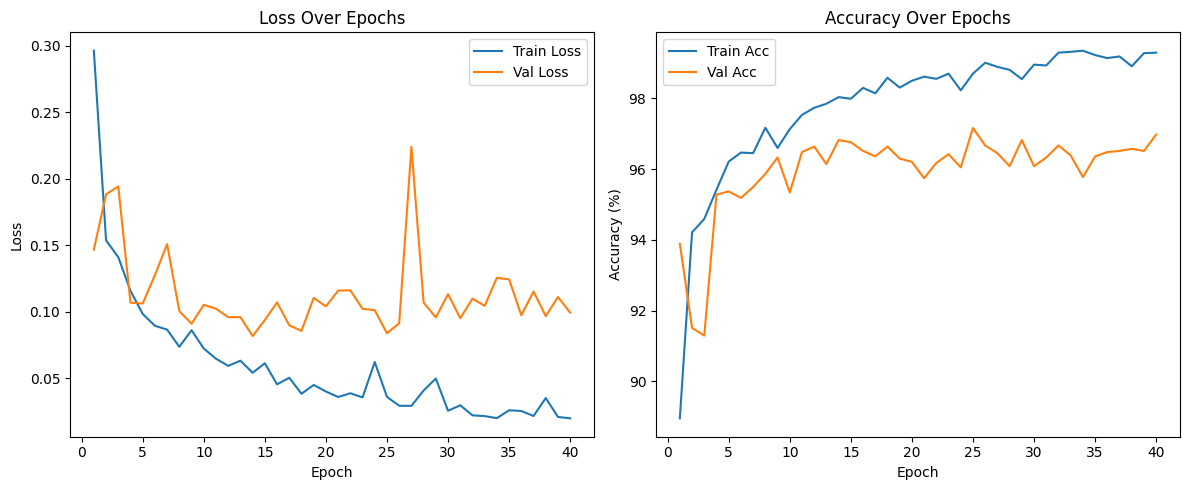

In [23]:
# Plot training graphs
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label="Train Acc")
plt.plot(range(1, num_epochs + 1), val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

ValueError: a must be greater than 0 unless no samples are taken